# Garmin and Charts

Resume session or login, and make sure to save the garth session for next time

In [1]:
import garth
from garth.exc import GarthException
from getpass import getpass

# saves local auth - not secure for shared computers
#TODO revisit
GARTH_HOME = ".garth"

try:
    garth.resume(GARTH_HOME)
    garth.client.username
except (GarthException, FileNotFoundError):
    email = input("Email: ")
    password = getpass("Password: ")
    garth.client.login(email, password)

garth.save(GARTH_HOME)

Email:  alanahr@gmail.com
Password:  ········


# Activities & Calories

[{'date': '2026-04-04', 'restingCalories': 1435, 'totalCalories': 2563, 'activeCalories': 1128}, {'date': '2026-04-05', 'restingCalories': 199, 'totalCalories': 330, 'activeCalories': 131}]
date
2026-04-04    5126
2026-04-05     660
dtype: int64


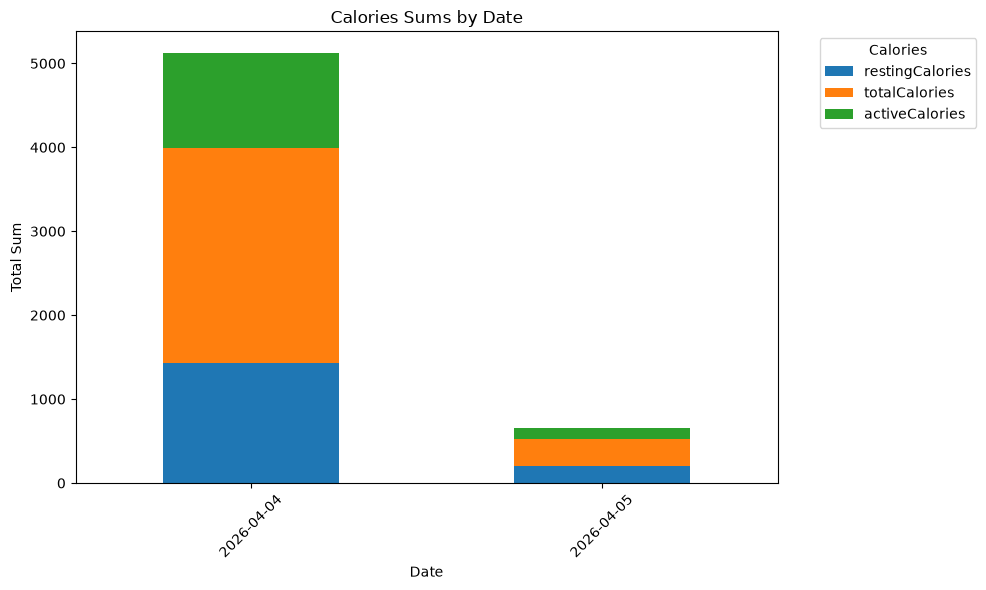

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import datetime

def get_week_dates(weeks_ago=0):
    """
    Calculates the dates for Monday through Sunday of the current week.

    Returns:
        A list of datetime.date objects for Monday to Sunday.

    Example:
        >>> get_week_dates(weeks_ago=1)
        [datetime.date(2023, 9, 28), ...]
    """
    # # Example usage:
    # week_dates = get_week_dates()
    # print("Dates for the current week (Monday-Sunday):")
    # for date in week_dates:
    #     # You can format the date as a string for better readability
    #     print(date.strftime("%Y-%m-%d, %A"))

    today = datetime.date.today()
    # Calculate the date of Monday in the current week
    # today.weekday() returns 0 for Monday, 1 for Tuesday, ..., 6 for Sunday
    # Subtract the current weekday number from today's date to get Monday's date
    monday = today - datetime.timedelta(days=today.weekday(), weeks=weeks_ago)
    # Generate the dates for the following 6 days (Tuesday to Sunday)
    week_dates = [monday + datetime.timedelta(days=i) for i in range(7)]
    return week_dates


def make_stacked_calories_chart(calories_list):
    import pandas as pd
    import matplotlib.pyplot as plt
    # Flatten the nested structure
    flattened_data = []
    for entry in calories_list["values"]:
        # Create a base row with the date
        row = {'date': entry['calendarDate']}
        # Pull the 'sum' from each activity into the top level of the row
        for calories_types, calories_value in entry['values'].items():
            row[calories_types] = calories_value
        flattened_data.append(row)
    print(flattened_data)
    # Create DataFrame and handle missing values (NaN) with 0
    df = pd.DataFrame(flattened_data).set_index('date').fillna(0)
    bottom = np.zeros(len(flattened_data))
    totals = df.sum(axis=1)
    print(totals)
    # Plotting
    ax = df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    plt.title('Calories Sums by Date')
    plt.xlabel('Date')
    plt.ylabel('Total Sum')
    plt.xticks(rotation=45)
    plt.legend(title="Calories", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## Date operations
today = datetime.date.today().strftime("%Y-%m-%d")
this_week = get_week_dates(weeks_ago=0)
this_mon = this_week[0].strftime("%Y-%m-%d")
this_sun = this_week[6].strftime("%Y-%m-%d")

## Activities
# activities_list = [Activity(activity_id=12341227613, activity_name='Cycling', activity_type=ActivityType(type_id=2, type_key='cycling', parent_type_id=17, is_hidden=False, restricted=False, trimmable=True), start_time_local=datetime.datetime(2026, 5, 27, 16, 14, 52), start_time_gmt=datetime.datetime(2026, 5, 27, 21, 14, 52), user_profile_id=None, is_multi_sport_parent=None, event_type=EventType(type_id=9, type_key='uncategorized', sort_order=10), summary=None, location_name='Chicago', distance=6842.41015625, duration=1435.2989501953125, elapsed_duration=1438.738037109375, moving_duration=1221.0, elevation_gain=9.125732421875, elevation_loss=8.125732421875, average_speed=4.767000198364258, max_speed=8.994999885559082, calories=228.0, average_hr=167.0, max_hr=183.0, owner_id=12345678, owner_display_name='12345678-753c-4a4c-8a8a-d7cbc10de5cd', owner_full_name='Full Name', steps=None, average_running_cadence_in_steps_per_minute=None, max_running_cadence_in_steps_per_minute=None)]
activities_list = garth.Activity.list(limit=30)

## Calories
calories_list= {'values': [{'calendarDate': '2026-04-04', 'values': {'restingCalories': 1435, 'totalCalories': 2563, 'activeCalories': 1128}}, {'calendarDate': '2026-04-05', 'values': {'restingCalories': 199, 'totalCalories': 330, 'activeCalories': 131}}], 'aggregations': {'restingCaloriesAverage': 1435.0, 'activeCaloriesAverage': 1128.0, 'totalCaloriesAverage': 2563.0}}
#calories_list = garth.connectapi("/usersummary-service/stats/daily/{0}/{1}".format(this_mon, this_sun), params={"statsType":"CALORIES", "currentDate":"{0}".format(today)})

## Charts
make_stacked_calories_chart(calories_list)